# 0 准备数据

In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import seaborn as sns
import pandas as pd
import re

%matplotlib inline

# 找个中文字体（跨平台支持）
def get_best_chinese_font():
    """获取最适合的中文字体，支持跨平台"""
    import platform

    # 根据操作系统选择字体策略
    system = platform.system()

    # 各系统的字体优先级
    font_priority = {
        'Windows': [
            'Microsoft YaHei',  # 微软雅黑
            'SimHei',  # 黑体
            'SimSun',  # 宋体
            'Arial Unicode MS',  # 跨平台
        ],
        'Darwin': [  # macOS
            'STHeiti',  # 黑体
            'Hiragino Sans GB',  # 冬青黑体
            'STSong',  # 宋体
            'Arial Unicode MS',
        ],
        'Linux': [
            'WenQuanYi Micro Hei',  # 文泉驿微米黑
            'Noto Sans CJK SC',  # Google Noto字体
            'DejaVu Sans',
            'Arial Unicode MS',
        ]
    }

    # 默认字体列表（跨平台）
    default_fonts = ['Arial Unicode MS', 'DejaVu Sans']

    # 获取系统字体列表
    try:
        available_fonts = [f.name for f in fm.fontManager.ttflist]

        # 按优先级查找字体
        priority_list = font_priority.get(system, default_fonts) + default_fonts

        for font_n in priority_list:
            if (font_n.lower() in font.lower() for font in available_fonts):
                # 找到具体的字体文件路径
                for font_info in fm.fontManager.ttflist:
                    if font_n.lower() in font_info.name.lower():
                        return font_n, font_info.fname

        # 如果找不到特定字体，尝试使用系统默认字体
        return None

    except Exception as e:
        print(f"字体检测失败: {e}")
        return None


# 获取最佳字体
font_name, font_path = get_best_chinese_font()
print(f"检测到中文字体: {font_name} 字体路径: {font_path}")
sns.set_theme(font=font_name)

df = pd.read_csv("1686117505649-题目4数据.csv", encoding="gbk")
df.head()

检测到中文字体: STHeiti 字体路径: /System/Library/AssetsV2/com_apple_MobileAsset_Font8/10e7a462a671950b802274fad767b566ff8457d1.asset/AssetData/STXIHEI.ttf


,positionId,positionName,companyFullName,companyShortName,companySize,financeStage,industryField,companyLabelList,firstType,positionLables,...,createTime,city,district,businessZones,salary,salaryMonth,workYear,jobNature,education,positionAdvantage
0,8280292,资深数据分析师,北京拉勾网络技术有限公司,拉勾网,500-2000人,D轮及以上,企业服务,"['五险一金', '弹性工作', '带薪年假', '免费两餐']",开发|测试|运维类,['数据分析'],...,2021/4/26 10:00,北京,海淀区,NaN,15k-30k,14,3-5年,全职,本科,"发展空间大,弹性工作制,领导Nice"
1,8437217,数据分析实习生,北京字节跳动网络技术有限公司,字节跳动,2000人以上,D轮及以上,"内容资讯,短视频","['扁平管理', '弹性工作', '就近租房补贴', '六险一金']",开发|测试|运维类,['后端开发'],...,2021/4/28 5:18,北京,海淀区,NaN,3k-6k,0,在校/应届,实习,本科,"下午茶,健身瑜伽,免费三餐,弹性工作"
2,6559839,数据分析师,欧科互动网络科技（北京）有限公司,欧科云链集团,500-2000人,不需要融资,区块链,"['节日礼物', '年度旅游', '扁平管理', '领导好']",产品|需求|项目类,['数据分析'],...,2021/4/26 16:03,北京,海淀区,"['西北旺', '上地', '清河']",25k-45k,0,5-10年,全职,本科,大牛团队 发展前景 薪资客观
3,8168535,数据分析师,欧科互动网络科技（北京）有限公司,欧科云链集团,500-2000人,不需要融资,区块链,"['节日礼物', '年度旅游', '扁平管理', '领导好']",产品|需求|项目类,"['商业', 'SQL', '数据分析']",...,2021/4/26 16:03,北京,海淀区,"['西北旺', '上地', '清河']",15k-30k,14,1-3年,全职,本科,发展前景好，大牛团队
4,8438943,数据分析师,北京拉勾网络技术有限公司,拉勾网,500-2000人,D轮及以上,"工具类产品,在线教育","['五险一金', '弹性工作', '带薪年假', '免费两餐']",产品|需求|项目类,"['数据分析', 'hive', 'SQL']",...,2021/4/26 10:00,北京,海淀区,NaN,15k-25k,0,1-3年,全职,本科,15薪


In [2]:
salary_pat_range = re.compile("^(\d+)[kK]-(\d+)[kK]$")
salary_pat_min = re.compile("^(\d+)[kK]以上$")

def extract_salary_range(salary_str: str):
    """
    Extract salary range from salary string.
    :param salary_str: The salary string. The expected pattern is '^(\d+)[kK]-(\d+)[kK]$'
    :return: The salary range.
    :rtype: pd.Series. [float, float]
    :raises: ValueError
    """
    if pd.isna(salary_str):
        return pd.Series([np.nan, np.nan])
    try:
        rm = salary_pat_range.match(salary_str)
        if rm is not None:
            return pd.Series([float(rm.group(1)), float(rm.group(2))])

        rm = salary_pat_min.match(salary_str)
        if rm is not None:
            salary_min = float(rm.group(1))
            return pd.Series([salary_min, salary_min])

        raise ValueError(
            f"Invalid salary string: {salary_str}. The expected pattern is '^(\d+)[kK]-(\d+)[kK]$' or '^(\d+)[kK]以上$'.")
    except Exception as e:
        print(e)
        return pd.Series([np.nan, np.nan])


df[["salary_min", "salary_max"]] = df["salary"].apply(extract_salary_range)
df["salary_avg"] = (df["salary_min"] + df["salary_max"]) / 2
df[["salary_min", "salary_max", "salary_avg"]].describe()


,salary_min,salary_max,salary_avg
count,3180.000000,3180.000000,3180.000000
mean,12.785849,21.905975,17.345912
std,7.209514,13.163775,10.087764
min,1.000000,2.000000,1.500000
25%,7.000000,12.000000,9.500000
50%,11.000000,20.000000,15.000000
75%,15.000000,30.000000,22.500000
max,50.000000,100.000000,75.000000


# 1 薪资相关

## 1.1 薪资分析

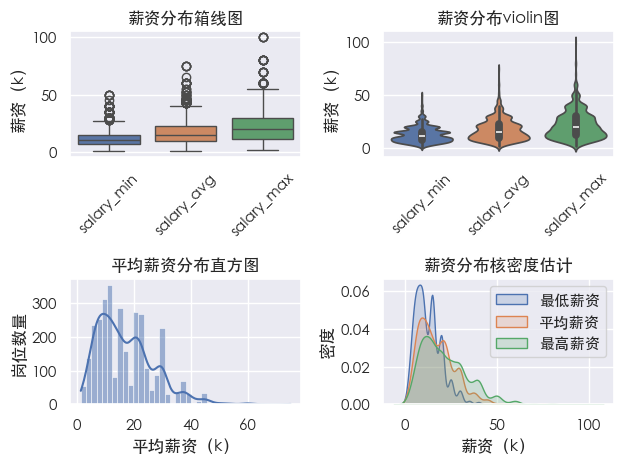

In [3]:
# 箱线图
plt.subplot(2, 2, 1)
sns.boxplot(df[["salary_min", "salary_avg", "salary_max"]])
plt.title("薪资分布箱线图")
plt.ylabel("薪资（k）")
plt.xticks(rotation=45)

# violin 图
plt.subplot(2, 2, 2)
sns.violinplot(df[["salary_min", "salary_avg", "salary_max"]])
plt.title("薪资分布violin图")
plt.ylabel("薪资（k）")
plt.xticks(rotation=45)

# 直方图
plt.subplot(2, 2, 3)
sns.histplot(df, x="salary_avg", bins=40, kde=True)
plt.title("平均薪资分布直方图")
plt.xlabel("平均薪资（k）")
plt.ylabel("岗位数量")

# 对比 min, avg, max
plt.subplot(2, 2, 4)
sns.kdeplot(df, x="salary_min", label="最低薪资", fill=True, alpha=0.2)
sns.kdeplot(df, x="salary_avg", label="平均薪资", fill=True, alpha=0.2)
sns.kdeplot(df, x="salary_max", label="最高薪资", fill=True, alpha=0.2)
plt.title("薪资分布核密度估计")
plt.xlabel("薪资（k）")
plt.ylabel("密度")
plt.legend()

plt.tight_layout()

## 1.2 不同城市薪资分布

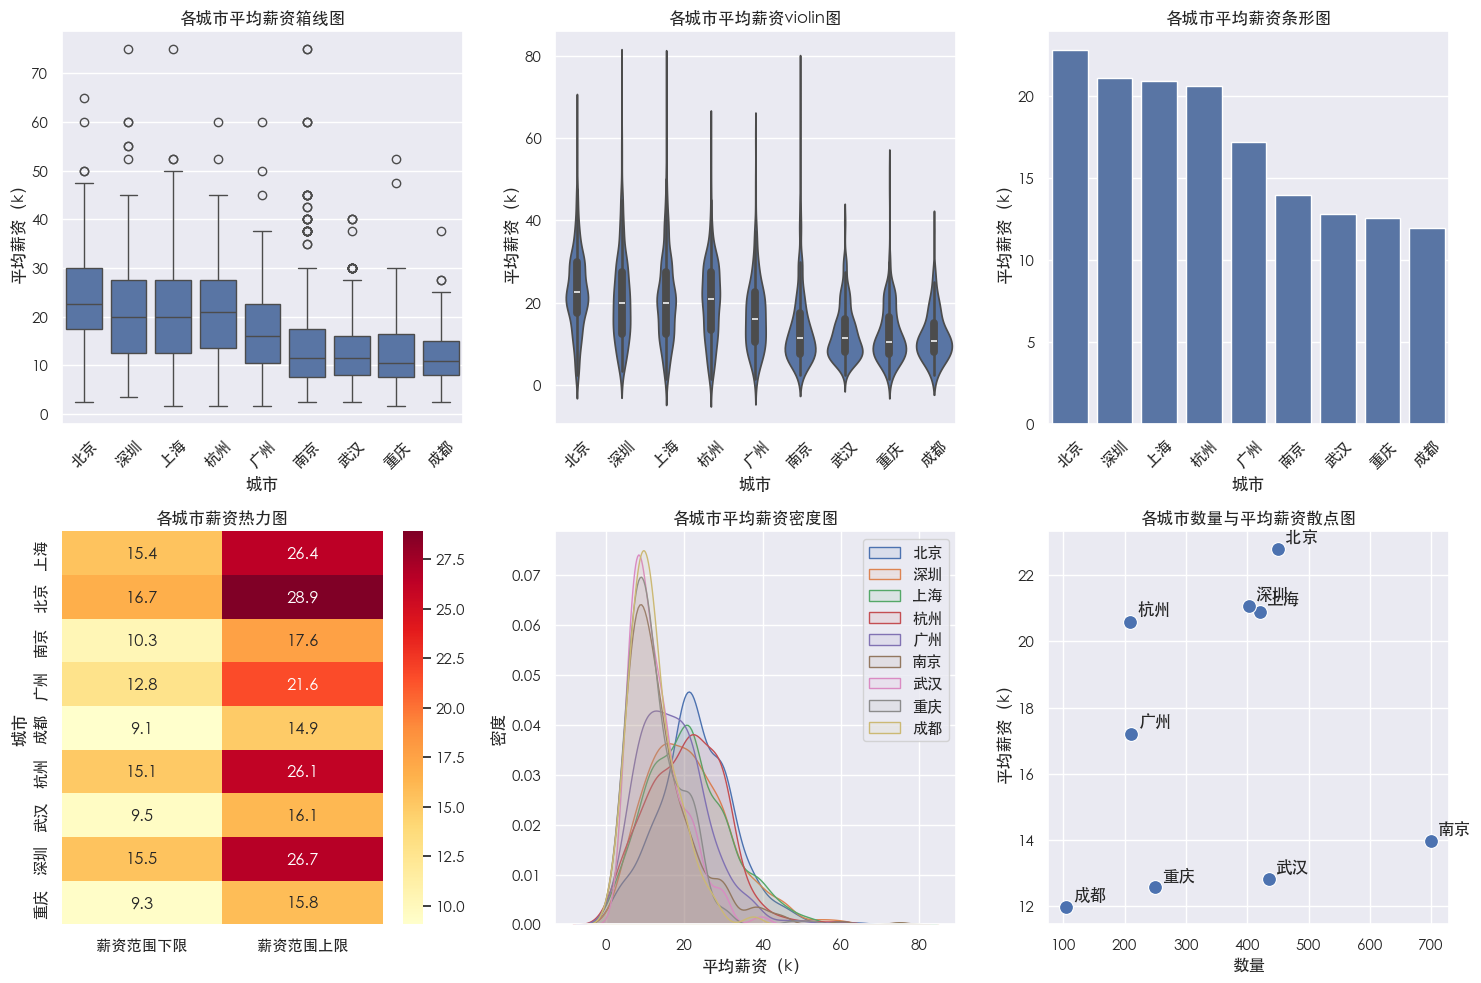

==== 城市薪资分析报告 ====
城市数量：9
各城市职位分布：
   城市   数量
0  南京  700
1  北京  450
2  武汉  435
3  上海  420
4  深圳  403
5  重庆  249
6  广州  210
7  杭州  209
8  成都  104
各城市薪资概况：
北京：
	职位数量：450
	薪资范围平均：16.7k - 28.9k
	平均薪资中位数：22.5k
	平均薪资标准差：9.6k
深圳：
	职位数量：403
	薪资范围平均：15.5k - 26.7k
	平均薪资中位数：20.0k
	平均薪资标准差：10.9k
上海：
	职位数量：420
	薪资范围平均：15.4k - 26.4k
	平均薪资中位数：20.0k
	平均薪资标准差：10.6k
杭州：
	职位数量：209
	薪资范围平均：15.1k - 26.1k
	平均薪资中位数：21.0k
	平均薪资标准差：9.7k
广州：
	职位数量：210
	薪资范围平均：12.8k - 21.6k
	平均薪资中位数：16.0k
	平均薪资标准差：9.0k
南京：
	职位数量：700
	薪资范围平均：10.3k - 17.6k
	平均薪资中位数：11.5k
	平均薪资标准差：9.5k
武汉：
	职位数量：435
	薪资范围平均：9.5k - 16.1k
	平均薪资中位数：11.5k
	平均薪资标准差：6.8k
重庆：
	职位数量：249
	薪资范围平均：9.3k - 15.8k
	平均薪资中位数：10.5k
	平均薪资标准差：7.1k
成都：
	职位数量：104
	薪资范围平均：9.1k - 14.9k
	平均薪资中位数：10.8k
	平均薪资标准差：6.1k


In [4]:
city_salary = df.groupby("city").agg({
    "salary_min": ["count", "mean", "std", "min", "max"],
    "salary_max": ["mean", "std", "min", "max"],
    "salary_avg": ["mean", "std", "min", "max", "median"]
}).round(2)
city_salary.columns = ['_'.join(col).strip() for col in city_salary.columns.values]

plt.figure(figsize=(15, 10))

city_order = city_salary.sort_values("salary_avg_mean", ascending=False).index

# 各城市平均薪资箱线图
plt.subplot(2, 3, 1)
sns.boxplot(df, x="city", y="salary_avg", order=city_order)
plt.title("各城市平均薪资箱线图")
plt.xlabel("城市")
plt.ylabel("平均薪资（k）")
plt.xticks(rotation=45)

# 各城市平均薪资 violin图
plt.subplot(2, 3, 2)
sns.violinplot(df, x="city", y="salary_avg", order=city_order)
plt.title("各城市平均薪资violin图")
plt.xlabel("城市")
plt.ylabel("平均薪资（k）")
plt.xticks(rotation=45)

# 各城市薪资条形图
plt.subplot(2, 3, 3)
sns.barplot(city_salary, x="city", y="salary_avg_mean", order=city_order)
plt.title("各城市平均薪资条形图")
plt.xlabel("城市")
plt.ylabel("平均薪资（k）")
plt.xticks(rotation=45)

# 热力图
plt.subplot(2, 3, 4)
sns.heatmap(
    city_salary[["salary_min_mean", "salary_max_mean"]],
    xticklabels=["薪资范围下限", "薪资范围上限"],
    annot=True,
    cmap="YlOrRd",
    fmt=".1f"
)
plt.title("各城市薪资热力图")
plt.ylabel("城市")

# 密度图
plt.subplot(2, 3, 5)
for city in city_order:
    city_salary_avg = df[df["city"] == city]["salary_avg"]
    sns.kdeplot(city_salary_avg, label=city, fill=True, alpha=0.1)
plt.title("各城市平均薪资密度图")
plt.xlabel("平均薪资（k）")
plt.ylabel("密度")
plt.legend()

# 数量与平均薪资散点图
plt.subplot(2, 3, 6)
sns.scatterplot(city_salary, x="salary_min_count", y="salary_avg_mean", s=100)
for city in city_order:
    plt.annotate(
        city,
        (city_salary.loc[city, "salary_min_count"], city_salary.loc[city, "salary_avg_mean"]),
        xytext=(5, 5),
        textcoords='offset points'
    )
plt.title("各城市数量与平均薪资散点图")
plt.xlabel("数量")
plt.ylabel("平均薪资（k）")

plt.tight_layout()
plt.show()

# 总结报告
print("==== 城市薪资分析报告 ====")
print(f"城市数量：{len(city_order)}")
print(f"各城市职位分布：")
city_salary_count = city_salary["salary_min_count"].sort_values(ascending=False)
city_salary_count.index.name = "城市"
city_salary_count = city_salary_count.reset_index(name="数量")
print(city_salary_count)

print(f"各城市薪资概况：")
for city in city_order:
    print(f"{city}：")
    print(f"\t职位数量：{city_salary.loc[city, 'salary_min_count']}")
    print(
        f"\t薪资范围平均：{city_salary.loc[city, 'salary_min_mean']:.1f}k - {city_salary.loc[city, 'salary_max_mean']:.1f}k")
    print(f"\t平均薪资中位数：{city_salary.loc[city, 'salary_avg_median']:.1f}k")
    print(f"\t平均薪资标准差：{city_salary.loc[city, 'salary_avg_std']:.1f}k")


## 1.3 N薪分布分析

==== N薪分布概况 ====
职位数量：3180
N薪为 0 的职位数量：1891
N薪为 NaN 的职位数量：0
有N薪的职位数量：1289
N薪信息缺失率：0.5946540880503145
缺失的 N 薪数据将被填充为 12


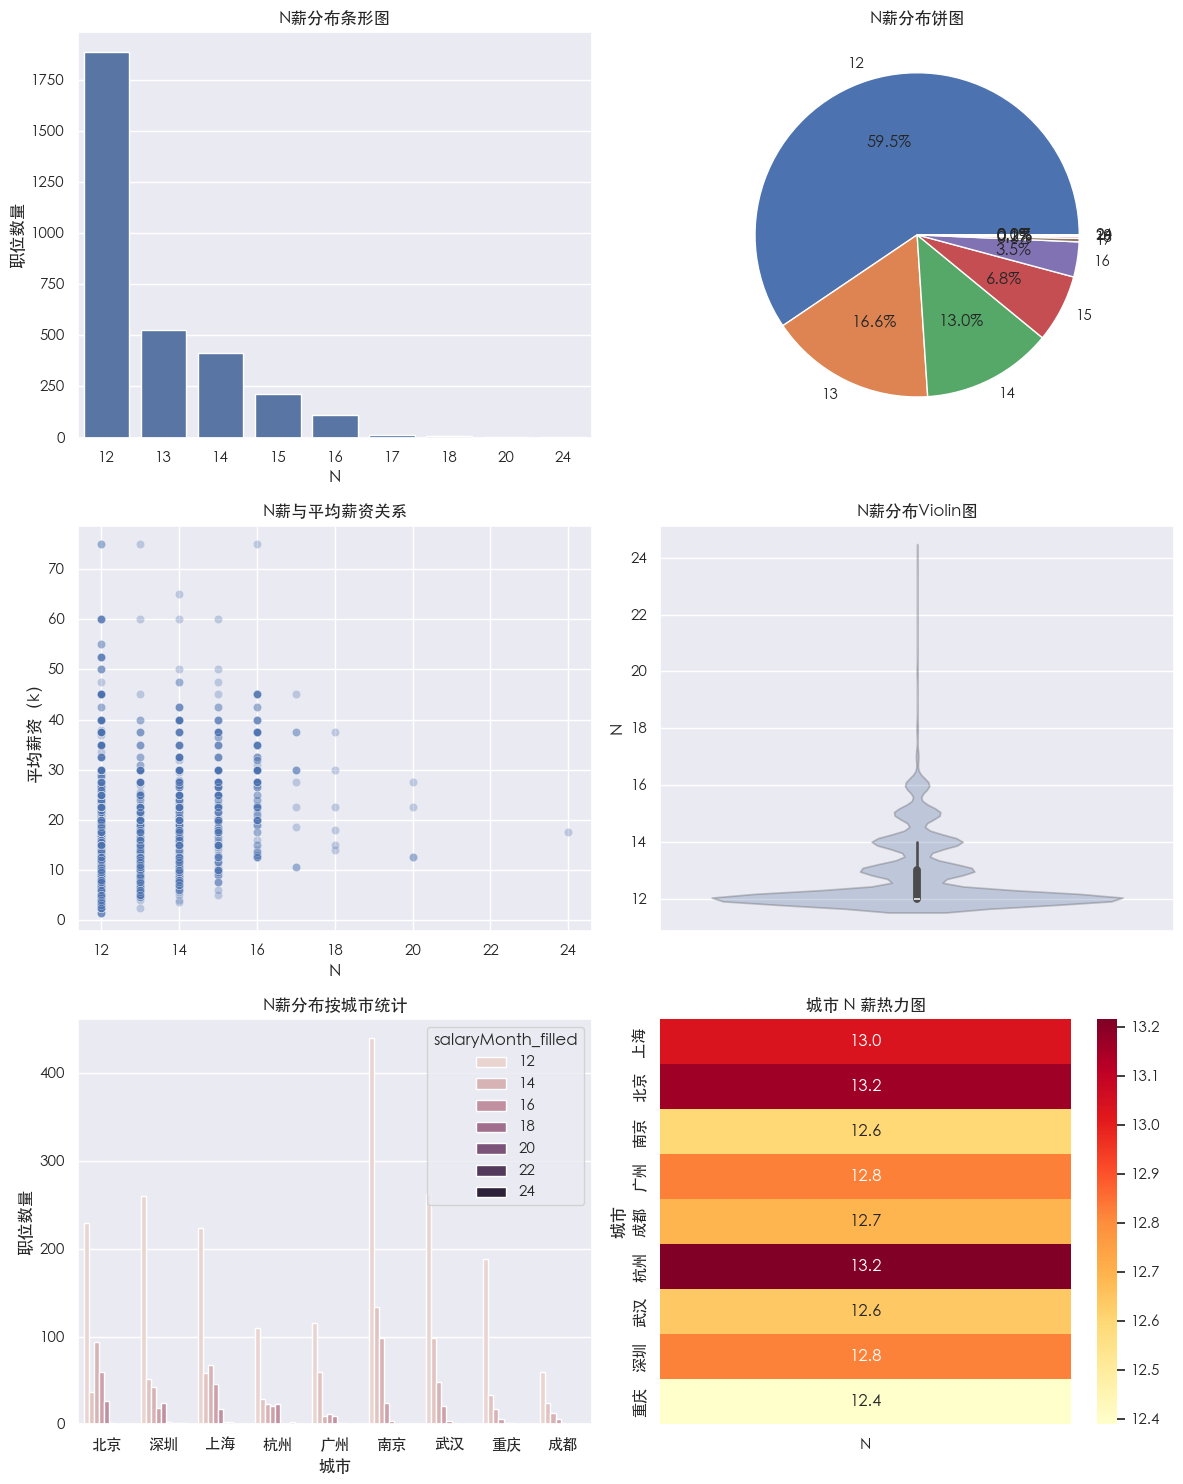

In [5]:
salary_month = df['salaryMonth']
salary_month_has_n = salary_month[salary_month > 0 & salary_month.notna()]
salary_month_filled = salary_month.apply(lambda x: x if x != 0 and not np.isnan(x) else 12)
df['salaryMonth_filled'] = salary_month_filled

# 概况
print("==== N薪分布概况 ====")
print(f"职位数量：{len(salary_month)}")
print(f"N薪为 0 的职位数量：{(salary_month == 0).sum()}")
print(f"N薪为 NaN 的职位数量：{(salary_month.isna()).sum()}")
print(f"有N薪的职位数量：{len(salary_month_has_n)}")
print(f"N薪信息缺失率：{(len(salary_month) - len(salary_month_has_n)) / len(salary_month)}")
print(f"缺失的 N 薪数据将被填充为 12")

plt.figure(figsize=(12, 15))
# 条形图
plt.subplot(3, 2, 1)
salary_month_counts = salary_month_filled.value_counts().sort_index()
sns.barplot(salary_month_counts)
plt.title("N薪分布条形图")
plt.xlabel("N")
plt.ylabel("职位数量")

# N薪分布饼图
plt.subplot(3, 2, 2)
plt.pie(salary_month_counts.values, labels=salary_month_counts.index, autopct='%1.1f%%')
plt.title("N薪分布饼图")

# N薪与平均薪资关系
plt.subplot(3, 2, 3)
sns.scatterplot(df, x='salaryMonth_filled', y='salary_avg', alpha=0.3)
plt.title("N薪与平均薪资关系")
plt.xlabel("N")
plt.ylabel("平均薪资（k）")

# N薪分布 violin 图
plt.subplot(3, 2, 4)
sns.violinplot(salary_month_filled, alpha=0.3)
plt.title("N薪分布Violin图")
plt.ylabel("N")

# 根据城市统计N薪分布
plt.subplot(3, 2, 5)
sns.countplot(df, x='city', hue='salaryMonth_filled', order=city_order)
plt.title("N薪分布按城市统计")
plt.xlabel("城市")
plt.ylabel("职位数量")

# 城市 N 薪热力图
plt.subplot(3, 2, 6)
city_salary_month_pivot = df.pivot_table(values='salaryMonth_filled', index='city', aggfunc='mean')
sns.heatmap(city_salary_month_pivot, annot=True, xticklabels="N", cmap="YlOrRd", fmt=".1f")
plt.title("城市 N 薪热力图")
plt.ylabel("城市")

plt.tight_layout()
plt.show()


## 1.4 工作年限与薪资分析

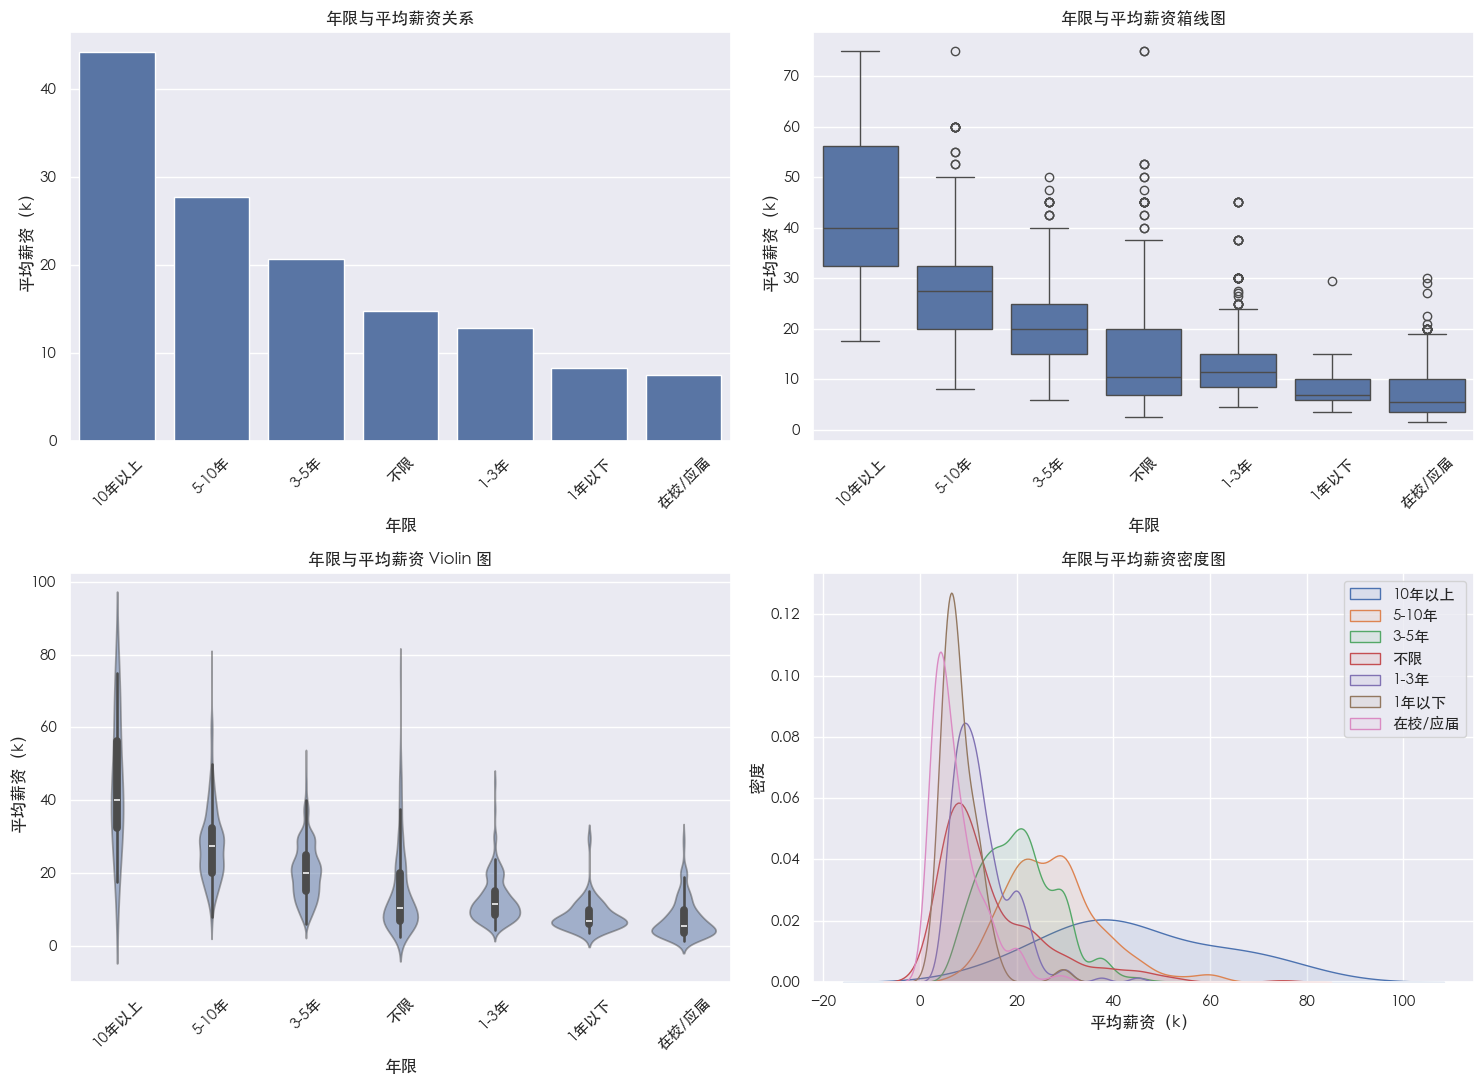

In [6]:
plt.figure(figsize=(15, 11))

work_year_count = df['workYear'].value_counts().sort_values(ascending=False)

# 年限与平均薪资关系
work_year_salary = df.groupby('workYear').agg(
    {
        "salary_avg": ["count", "mean", "std", "min", "max", "median"],
        "salary_min": ["mean"],
        "salary_max": ["mean"],
    }
).round(2).sort_values(("salary_avg", "mean"), ascending=False)

work_year_salary.columns = ['_'.join(multi_index).strip() for multi_index in work_year_salary.columns.values]

plt.subplot(2, 2, 1)
sns.barplot(work_year_salary, x='workYear', y='salary_avg_mean')
plt.title("年限与平均薪资关系")
plt.xlabel("年限")
plt.ylabel("平均薪资（k）")
plt.xticks(rotation=45)

# 年限与平均薪资箱线图
plt.subplot(2, 2, 2)
sns.boxplot(df, x='workYear', y='salary_avg', order=work_year_salary.index)
plt.title("年限与平均薪资箱线图")
plt.xlabel("年限")
plt.ylabel("平均薪资（k）")
plt.xticks(rotation=45)

# 年限与平均薪资 violin 图
plt.subplot(2, 2, 3)
sns.violinplot(df, x='workYear', y='salary_avg', order=work_year_salary.index, alpha=0.5)
plt.title("年限与平均薪资 Violin 图")
plt.xlabel("年限")
plt.ylabel("平均薪资（k）")
plt.xticks(rotation=45)

# 年限与平均薪资密度图
plt.subplot(2, 2, 4)
for work_year in work_year_salary.index:
    df_work_year = df[df['workYear'] == work_year]
    sns.kdeplot(df_work_year, x="salary_avg", label=work_year, fill=True, alpha=0.1)
plt.title("年限与平均薪资密度图")
plt.xlabel("平均薪资（k）")
plt.ylabel("密度")
plt.legend()

plt.tight_layout()
plt.show()

# 2 职位分析

## 2.1 不同城市职位数量


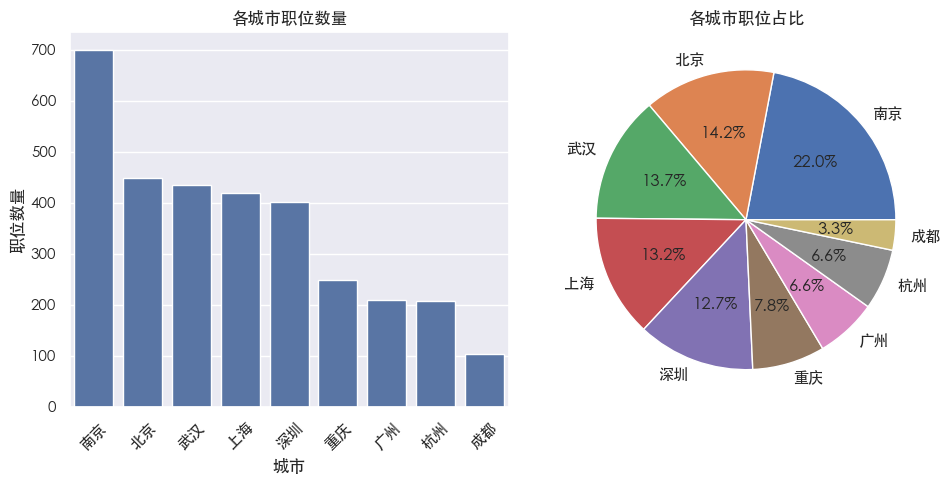

In [7]:
city_position_counts = df['city'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 5))

# 条形图
plt.subplot(1, 2, 1)
sns.barplot(city_position_counts)
plt.title("各城市职位数量")
plt.xlabel("城市")
plt.ylabel("职位数量")
plt.xticks(rotation=45)

# 饼图
plt.subplot(1, 2, 2)
plt.pie(city_position_counts, labels=city_position_counts.index, autopct='%1.1f%%')
plt.title("各城市职位占比")

plt.tight_layout()
plt.show()

## 2.2 公司融资情况


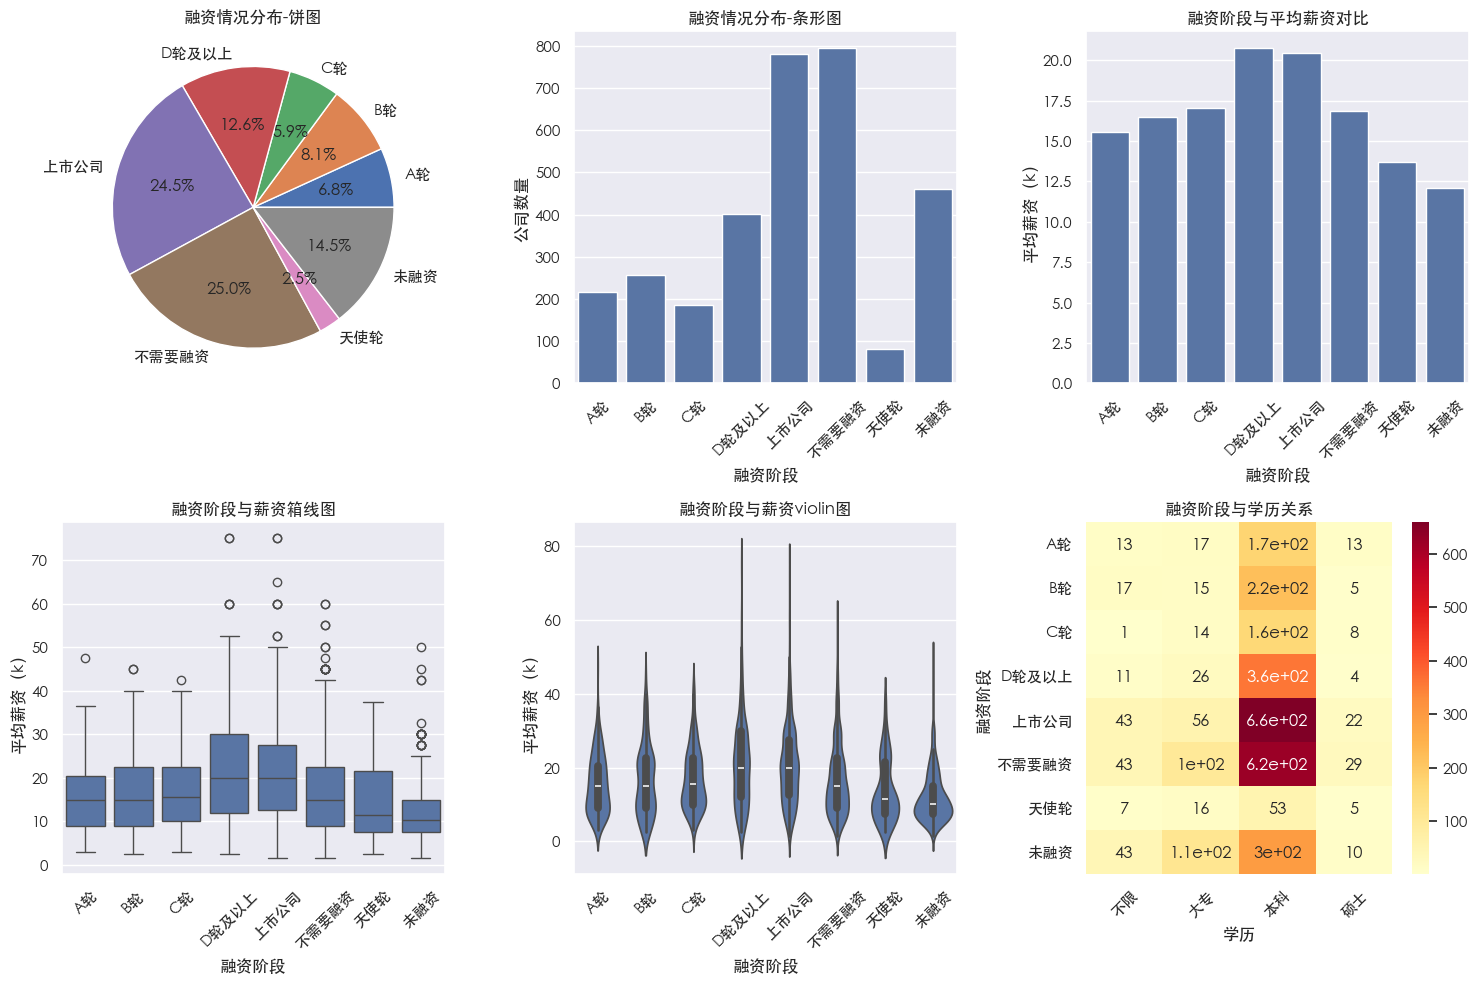

In [8]:
finance_stage_counts = df['financeStage'].value_counts().sort_index()

plt.figure(figsize=(15, 10))

# pie
plt.subplot(2, 3, 1)
plt.pie(finance_stage_counts, labels=finance_stage_counts.index, autopct='%1.1f%%')
plt.title("融资情况分布-饼图")

# bar
plt.subplot(2, 3, 2)
sns.barplot(finance_stage_counts)
plt.title("融资情况分布-条形图")
plt.xlabel("融资阶段")
plt.ylabel("公司数量")
plt.xticks(rotation=45)

# 融资阶段与平均薪资对比
finance_salary = df.groupby('financeStage').agg({
    'salary_avg': ['count', 'mean', 'std', 'min', 'max']
}).round(2)
finance_salary.columns = ['_'.join(multi_index) for multi_index in finance_salary.columns.values]

plt.subplot(2, 3, 3)
sns.barplot(finance_salary, x='financeStage', y='salary_avg_mean', order=finance_stage_counts.index)
plt.title("融资阶段与平均薪资对比")
plt.xlabel("融资阶段")
plt.ylabel("平均薪资（k）")
plt.xticks(rotation=45)

# 融资阶段与薪资箱线图
plt.subplot(2, 3, 4)
sns.boxplot(df, x='financeStage', y='salary_avg', order=finance_stage_counts.index)
plt.title("融资阶段与薪资箱线图")
plt.xlabel("融资阶段")
plt.ylabel("平均薪资（k）")
plt.xticks(rotation=45)

# 融资阶段与薪资violin图
plt.subplot(2, 3, 5)
sns.violinplot(df, x='financeStage', y='salary_avg', order=finance_stage_counts.index)
plt.title("融资阶段与薪资violin图")
plt.xlabel("融资阶段")
plt.ylabel("平均薪资（k）")
plt.xticks(rotation=45)

# 融资阶段与学历关系
plt.subplot(2, 3, 6)
finance_education_cross = pd.crosstab(df["financeStage"], df["education"])
sns.heatmap(finance_education_cross, cmap="YlOrRd", annot=True)
plt.title("融资阶段与学历关系")
plt.xlabel("学历")
plt.ylabel("融资阶段")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## 2.3 不同行业公司数量

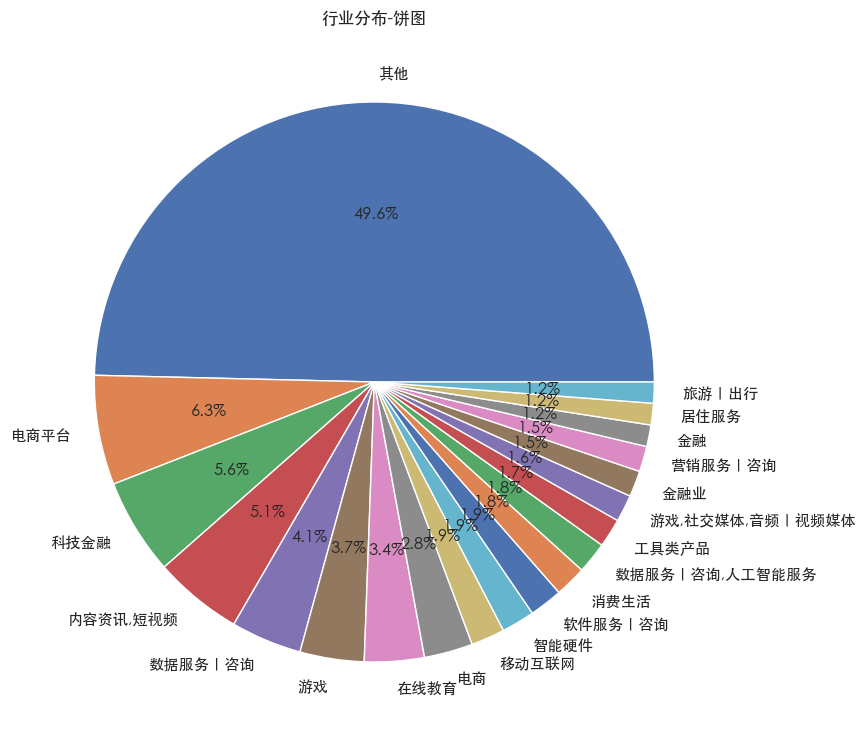

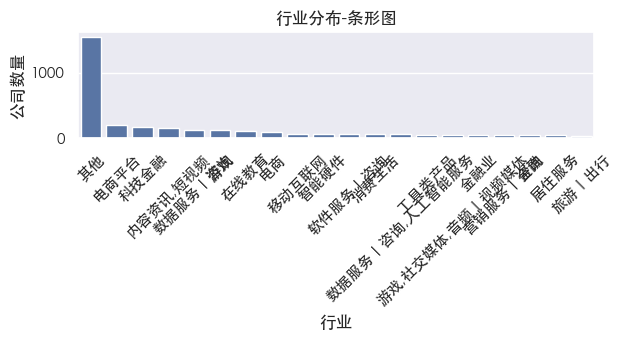

In [9]:
industry_counts = df['industryField'].value_counts().sort_values(ascending=False)


def get_industry_topn(series: pd.Series, n: int):
    topn = series[:n]
    topn.loc['其他'] = series[n:].sum()
    topn = topn.sort_values(ascending=False)
    return topn


top20 = get_industry_topn(industry_counts, 20)

plt.figure(figsize=(20, 20))

# 分布饼图
plt.subplot(2, 1, 1)
plt.pie(top20, labels=top20.index, autopct='%1.1f%%')
plt.title("行业分布-饼图")
plt.show()

# 分布条形图
plt.subplot(2, 1, 2)
sns.barplot(top20)
plt.title("行业分布-条形图")
plt.xlabel("行业")
plt.ylabel("公司数量")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## 2.4 工作经验分析

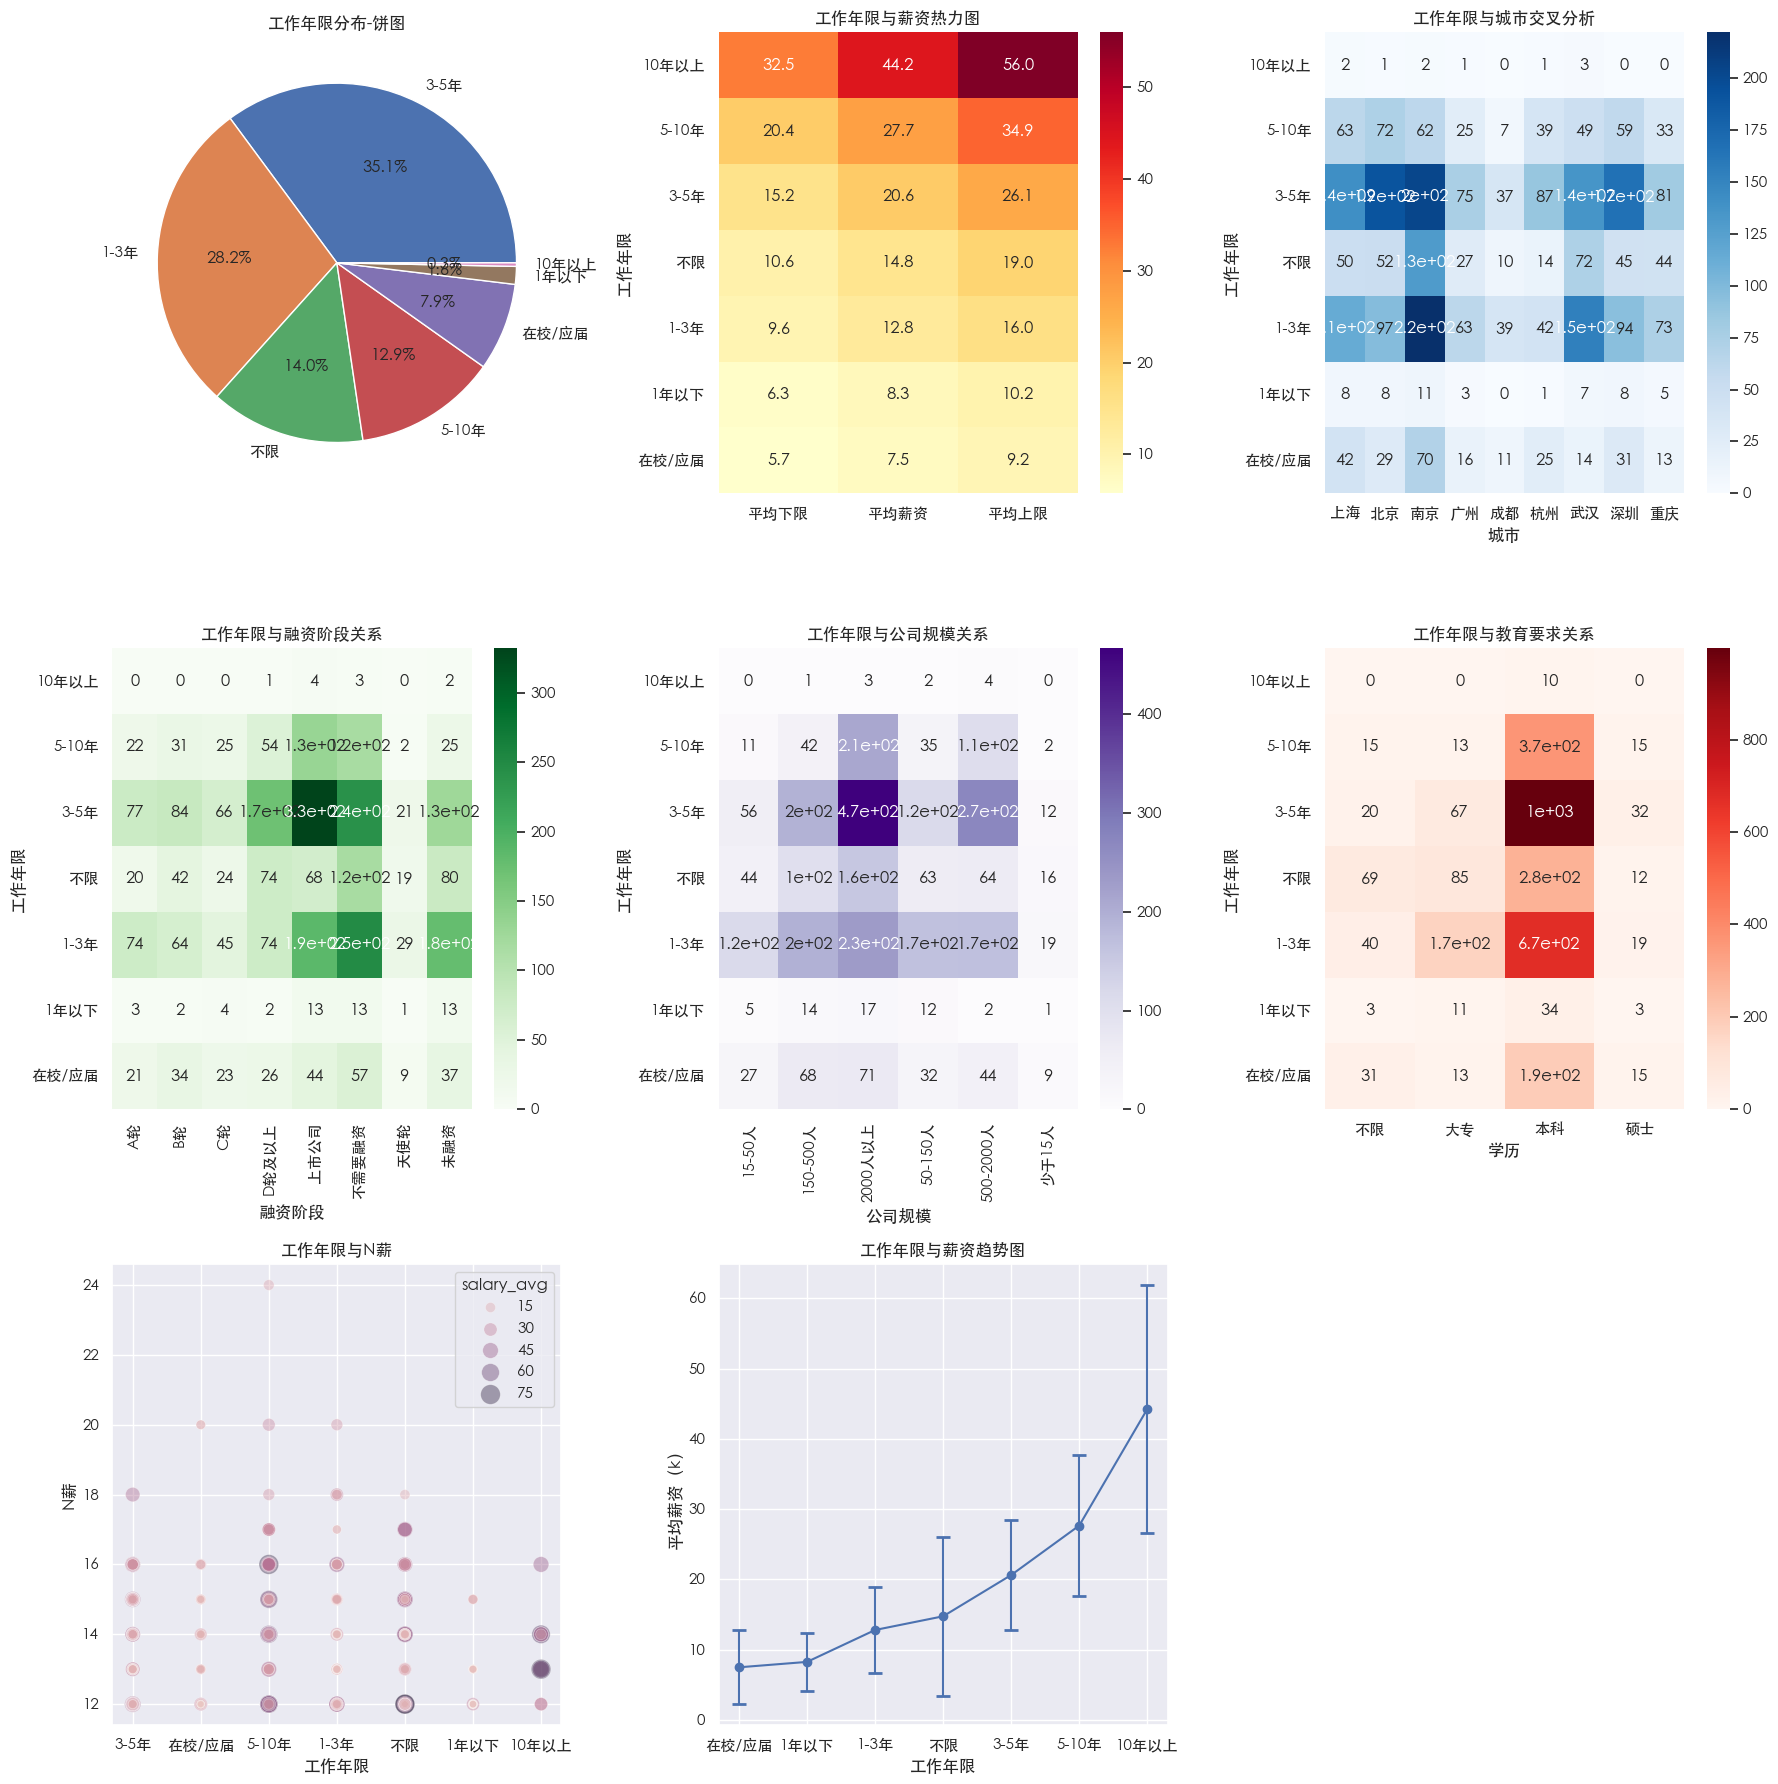

In [10]:
plt.figure(figsize=(18, 18))

# 1. 分布饼图
plt.subplot(3, 3, 1)
plt.pie(work_year_count, labels=work_year_count.index, autopct='%1.1f%%')
plt.title("工作年限分布-饼图")

# 2. 年限与薪资热力图
plt.subplot(3, 3, 2)
sns.heatmap(work_year_salary[["salary_min_mean", "salary_avg_mean", "salary_max_mean"]],
            xticklabels=['平均下限', '平均薪资', '平均上限'], fmt=".1f", cmap="YlOrRd", annot=True)
plt.title("工作年限与薪资热力图")
plt.ylabel("工作年限")

# 3. 年限与城市交叉分析
plt.subplot(3, 3, 3)
work_year_city_cross = pd.crosstab(df["workYear"], df["city"])
work_year_city_cross = work_year_city_cross.reindex(work_year_salary.index)
sns.heatmap(work_year_city_cross, cmap="Blues", annot=True)
plt.title("工作年限与城市交叉分析")
plt.xlabel("城市")
plt.ylabel("工作年限")

# 4. 年限与融资阶段关系
plt.subplot(3, 3, 4)
work_year_finance_cross = pd.crosstab(df["workYear"], df["financeStage"])
work_year_finance_cross = work_year_finance_cross.reindex(work_year_salary.index)
sns.heatmap(work_year_finance_cross, cmap="Greens", annot=True)
plt.title("工作年限与融资阶段关系")
plt.xlabel("融资阶段")
plt.ylabel("工作年限")

# 5. 年限与公司规模关系
plt.subplot(3, 3, 5)
work_year_size_cross = pd.crosstab(df["workYear"], df["companySize"])
work_year_size_cross = work_year_size_cross.reindex(work_year_salary.index)
sns.heatmap(work_year_size_cross, cmap="Purples", annot=True)
plt.title("工作年限与公司规模关系")
plt.xlabel("公司规模")
plt.ylabel("工作年限")

# 6. 年限与学历关系
plt.subplot(3, 3, 6)
work_year_education_cross = pd.crosstab(df["workYear"], df["education"])
work_year_education_cross = work_year_education_cross.reindex(work_year_salary.index)
sns.heatmap(work_year_education_cross, cmap="Reds", annot=True)
plt.title("工作年限与教育要求关系")
plt.xlabel("学历")
plt.ylabel("工作年限")

# 7. 年限-N薪
plt.subplot(3, 3, 7)
sns.scatterplot(df, x="workYear", y="salaryMonth_filled", size='salary_avg', hue='salary_avg', sizes=(20, 200),
                alpha=0.4)
plt.title("工作年限与N薪")
plt.xlabel("工作年限")
plt.ylabel("N薪")

# 8. 年限-薪资趋势图
plt.subplot(3, 3, 8)
work_year_salary_reverse = work_year_salary.sort_values(by="salary_avg_mean", ascending=True)
plt.errorbar(work_year_salary_reverse.index, work_year_salary_reverse['salary_avg_mean'], yerr=work_year_salary_reverse['salary_avg_std'],
             fmt='o-', capsize=5, capthick=2)
plt.title("工作年限与薪资趋势图")
plt.xlabel("工作年限")
plt.ylabel("平均薪资（k）")

plt.tight_layout()
plt.show()


## 2.5 职位标签：词云制作

总标签数量：8987
去重标签数量：1037
最常见的20个岗位标签：
	数据分析: 978
	电商平台: 286
	SQL: 214
	运营: 201
	Python: 196
	MySQL: 167
	大数据: 158
	数据挖掘: 155
	游戏: 151
	数据服务｜咨询: 151
	电商: 145
	BI: 112
	需求分析: 111
	用户增长: 110
	数据仓库: 108
	数据运营: 101
	移动互联网: 98
	数仓建模: 94
	Hadoop: 94
	商业: 93


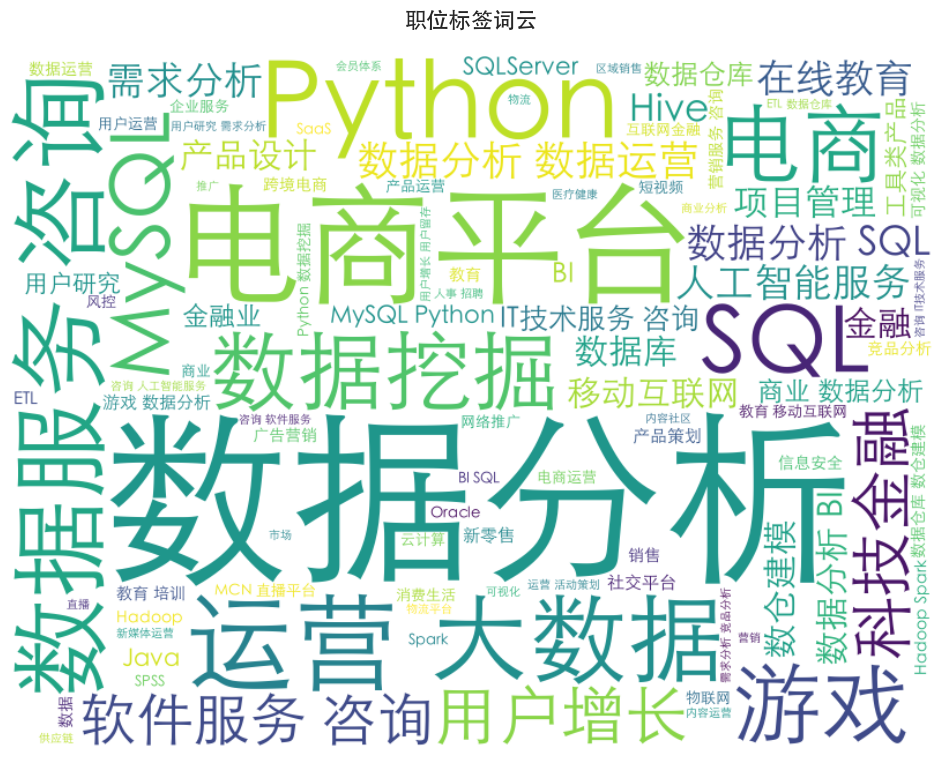

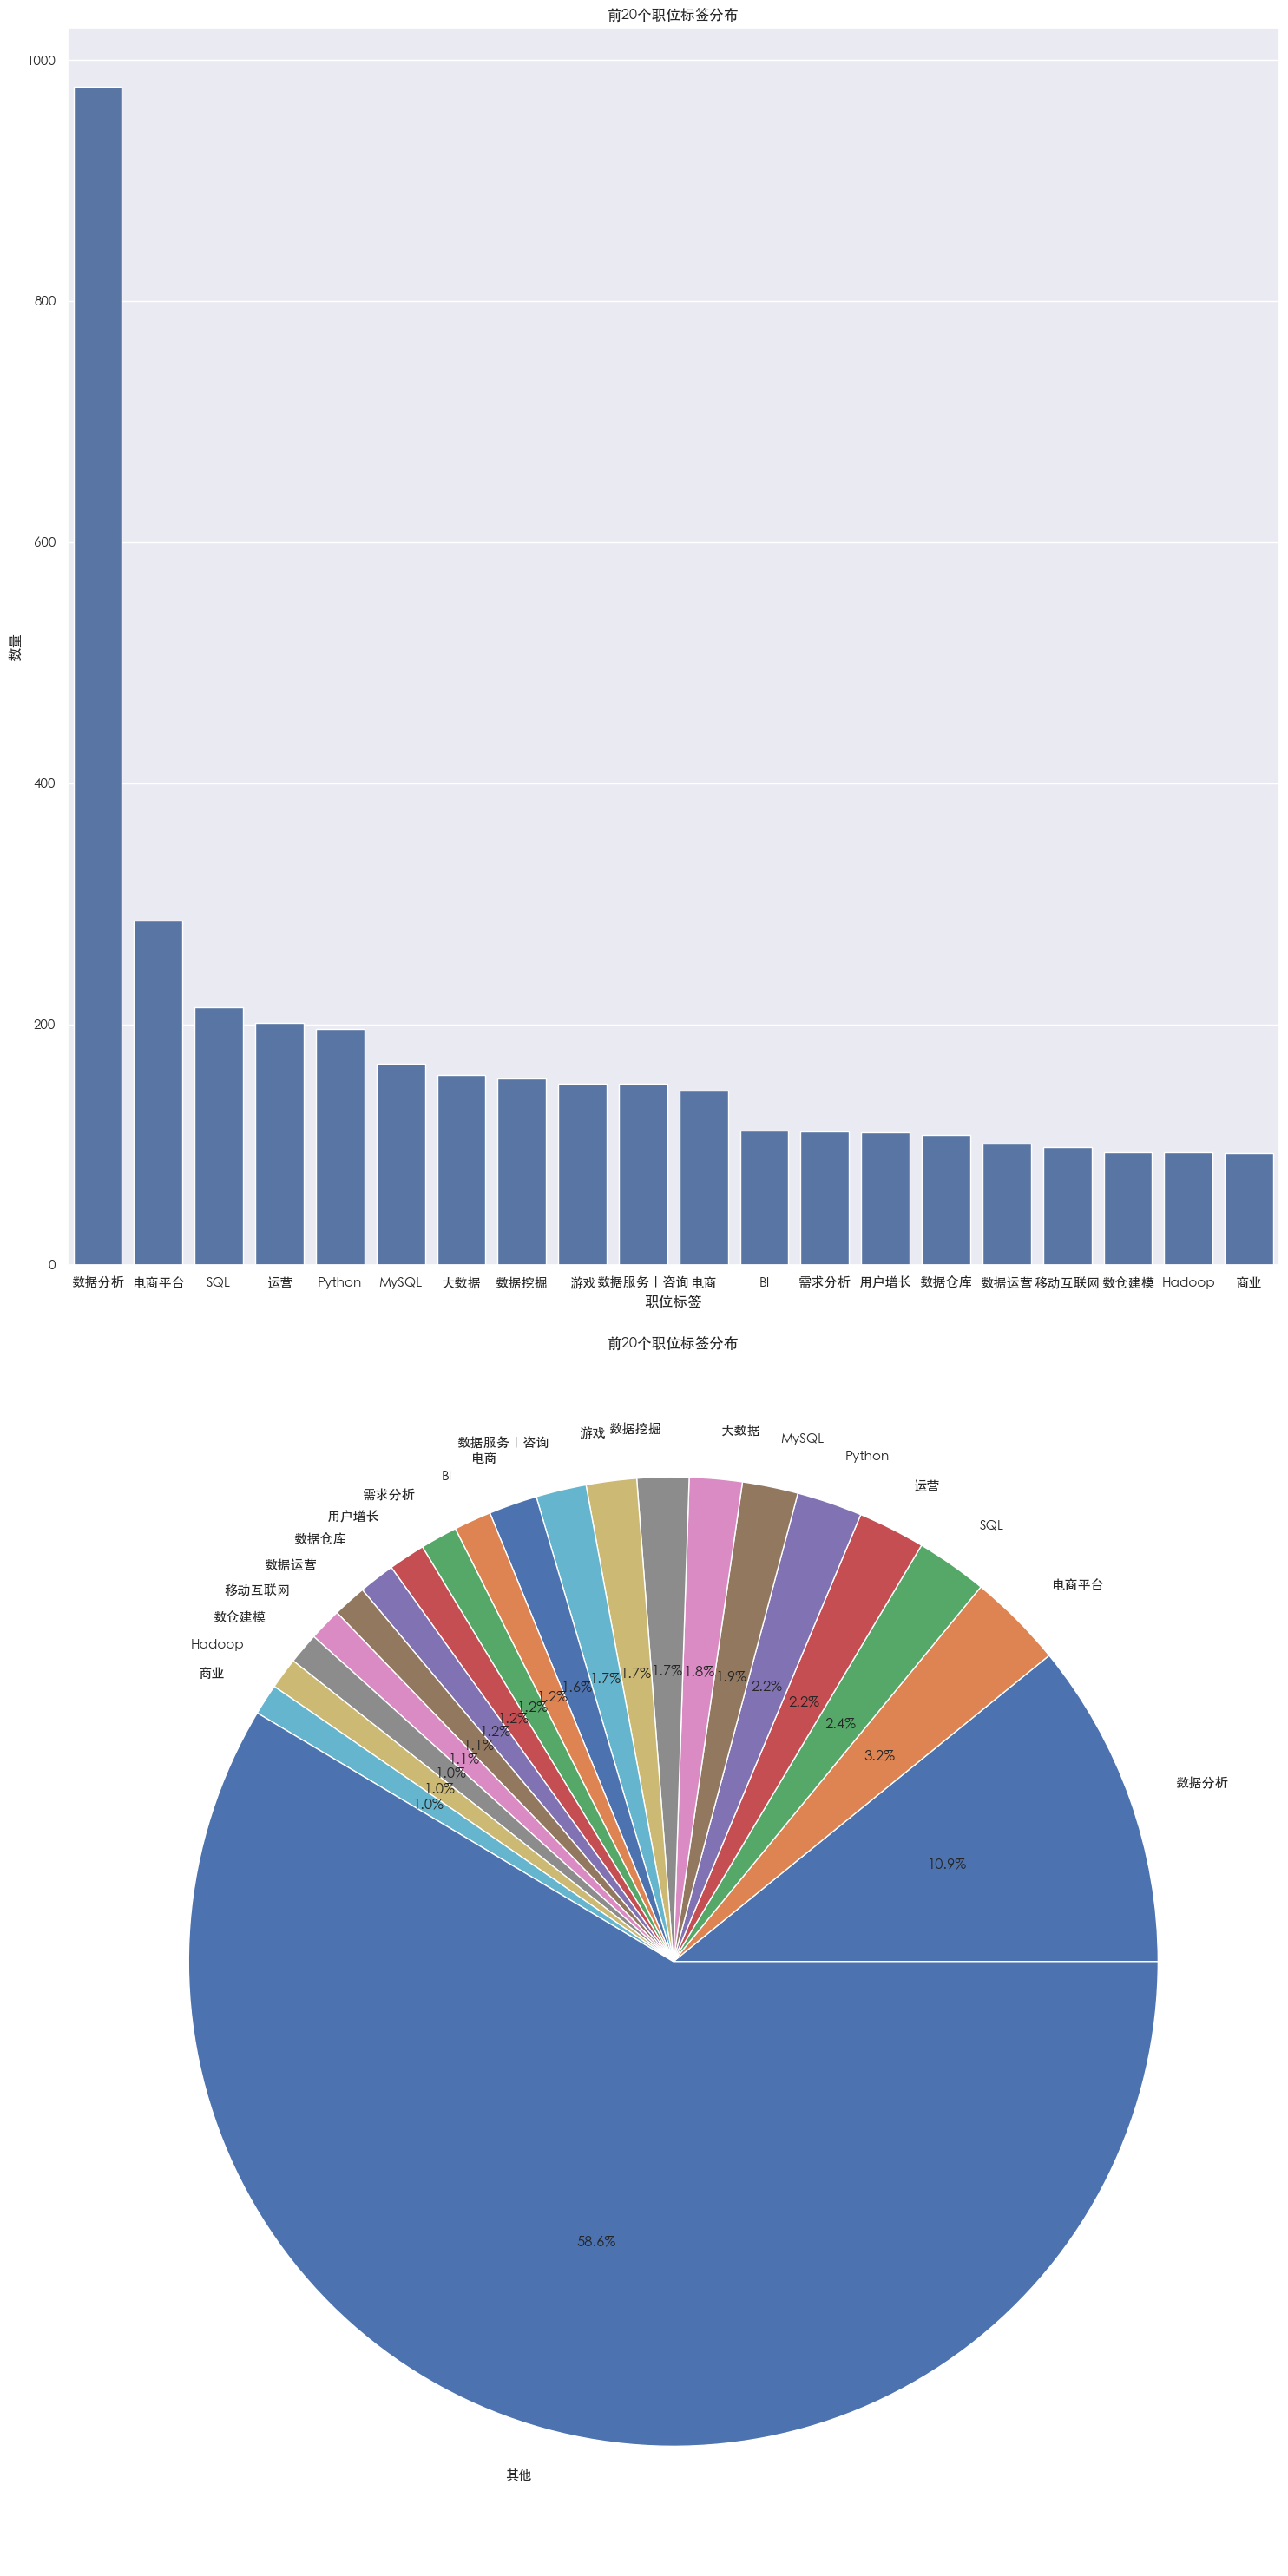

In [11]:
import ast
import matplotlib.font_manager as fm
from collections import Counter
from wordcloud import WordCloud

position_label_strs = df['positionLables'].dropna()


def parse_array_str(array_str):
    if pd.isna(array_str):
        return []
    try:
        if not isinstance(array_str, str):
            raise ValueError("array_str is not a string")

        if array_str.startswith('['):
            return ast.literal_eval(array_str)
        else:
            return [ele.strip() for ele in array_str.split(',') if ele.strip() != '']
    except Exception as e:
        print(e)
        return []


all_labels = []
for position_labels_str in position_label_strs:
    all_labels.extend(parse_array_str(position_labels_str))

print(f"总标签数量：{len(all_labels)}")
print(f"去重标签数量：{len(set(all_labels))}")

# 词频
label_freq = Counter(all_labels)
print("最常见的20个岗位标签：")
for label, freq in label_freq.most_common(20):
    print(f"\t{label}: {freq}")

# 词云
text = " ".join(all_labels)

wordcloud = WordCloud(
    width=800,
    height=600,
    background_color="white",
    max_words=100,
    relative_scaling=0.5,
    font_path=font_path
).generate(text)

plt.figure(figsize=(12, 9))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("职位标签词云", fontsize=16, pad=20)

plt.show()

plt.figure(figsize=(15, 30))
# 分布条形图
position_labels_top20 = label_freq.most_common(20)
top20_labels, top20_counts = zip(*position_labels_top20)

plt.subplot(2, 1, 1)
sns.barplot(x=top20_labels, y=top20_counts)
plt.title("前20个职位标签分布")
plt.xlabel("职位标签")
plt.ylabel("数量")

# pie
plt.subplot(2, 1, 2)
other_count = sum(count for label, count in label_freq.most_common()[20:])
pie_labels = list(top20_labels) + ["其他"]
pie_counts = list(top20_counts) + [other_count]
plt.pie(pie_counts, labels=pie_labels, autopct='%1.1f%%')
plt.title("前20个职位标签分布")

plt.tight_layout()
plt.show()